In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.lept import EncodedLEPTDataset
from peint.models.modules.lept_module import LEPTModule
from peint.models.nets.lept import LEPT

from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab
from esm.data import Alphabet

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-11-01_03-10-47/checkpoints")
# ckpt_path = ckpt_dir / "last.ckpt"
ckpt_path = ckpt_dir / "epoch_006.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# create a fresh peint model with the same hyperparameters as the training run
module: LEPTModule = LEPTModule.load_from_checkpoint(ckpt_path, map_location=device, strict=True)
module = module.eval()
net: LEPT = module.net
vocab: Vocab = net.vocab

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [4]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = EncodedLEPTDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        swap_prob=0.0,
        sep_token=".",
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        x, y, t, x_sizes, y_sizes = batch

        # transition objective
        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            Z_x = net.encode(x, x_sizes)
            Z_y_hat = net.exp(Z_x, t=t)
            y_attn_mask = (y != vocab.pad_idx).long()
            logits = net.decoder(y[:, :-1], Z_y_hat, y_attn_mask[:, :-1])

        nll = F.cross_entropy(
            logits.transpose(1, 2),
            y[:, 1:],
            ignore_index=vocab.pad_idx,
            reduction="none",
        )  # (bs, seq_len-1)

        yt_mask = y_attn_mask[:, :-1].bool()
        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(t.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

## Infer perplexity on test set data

In [7]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d3.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=20)

Inference:   2%|█▋                                                                                                 | 19/1075 [00:15<14:04,  1.25it/s]


In [11]:
print('test perplexity: ', np.mean(ppl))

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch": bls[:,0],
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("notebooks/inf_eval/lept_model_d3.csv", index=False)

test perplexity:  1.2236422


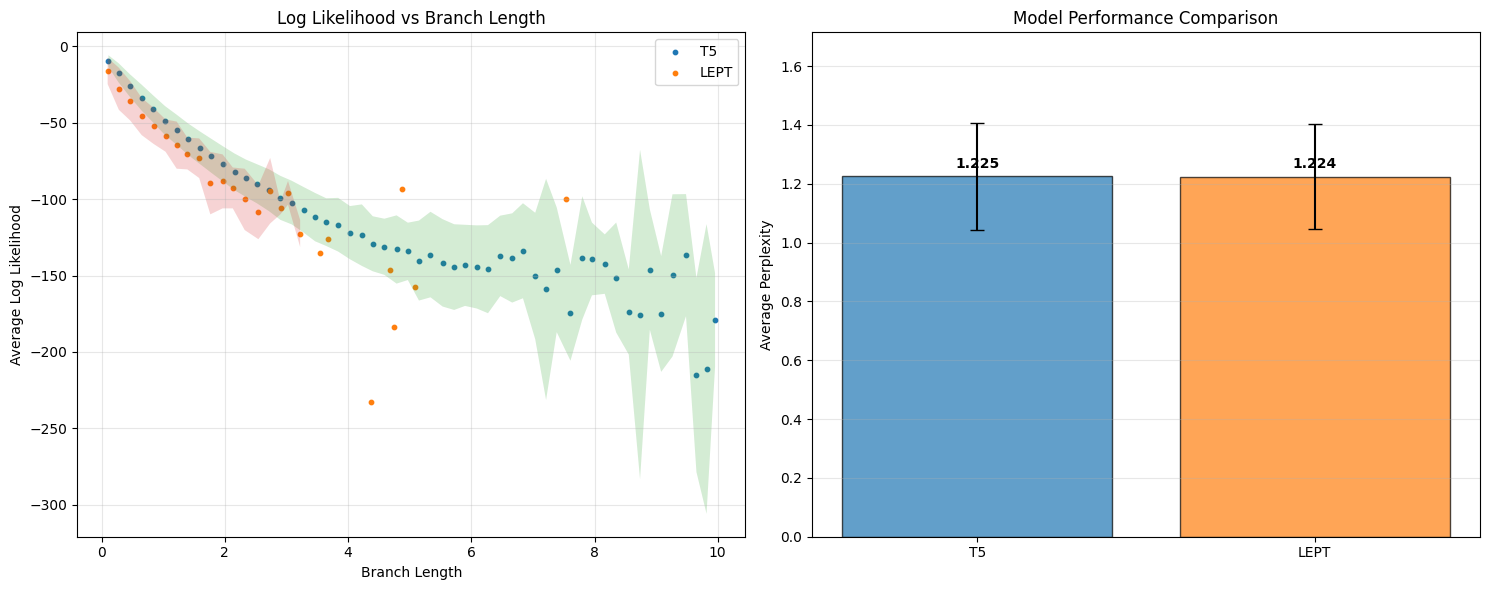

In [12]:
peint_df = pd.read_csv("notebooks/inf_eval/ctmc_model_d4.csv")
lept_df = pd.read_csv("notebooks/inf_eval/lept_model_d3.csv")

# plot the binned likelihoods according to the branch length
quantile_10 = pd.concat([peint_df.branch, lept_df.branch]).quantile(0.15)
peint_df["time_bin"] = peint_df.branch // quantile_10.astype(float)
lept_df["time_bin"] = lept_df.branch // quantile_10.astype(float)

# remove all with time_bin > 10
peint_df = peint_df[peint_df.branch <= 10.0]
lept_df = lept_df[lept_df.branch <= 10.0]

bin_cols = ['time_bin', 'branch', 'log_likelihood']
binned_peint_df = peint_df[bin_cols].groupby("time_bin").mean()
binned_lept_df = lept_df[bin_cols].groupby("time_bin").mean()

# Add confidence intervals as shaded areas
binned_peint_std = peint_df[bin_cols].groupby("time_bin").std()
binned_lept_std = lept_df[bin_cols].groupby("time_bin").std()

# fig, ax = plt.subplots(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot - existing likelihood vs branch length plot
ax1.scatter(binned_peint_df.branch, binned_peint_df.log_likelihood, label="T5", s=10)
ax1.scatter(binned_lept_df.branch, binned_lept_df.log_likelihood, label="LEPT", s=10)

# Add confidence intervals
ax1.fill_between(
    binned_peint_df.branch,
    binned_peint_df.log_likelihood - binned_peint_std.log_likelihood,
    binned_peint_df.log_likelihood + binned_peint_std.log_likelihood,
    alpha=0.2,
)

ax1.fill_between(
    binned_lept_df.branch,
    binned_lept_df.log_likelihood - binned_lept_std.log_likelihood,
    binned_lept_df.log_likelihood + binned_lept_std.log_likelihood,
    alpha=0.2,
)

ax1.set_xlabel("Branch Length")
ax1.set_ylabel("Average Log Likelihood")
ax1.set_title("Log Likelihood vs Branch Length")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot - average perplexity comparison with error bars
models = ['T5', 'LEPT']
avg_perplexities = [peint_df.perplexity.mean(), lept_df.perplexity.mean()]
std_perplexities = [peint_df.perplexity.std(), lept_df.perplexity.std()]
colors = ['tab:blue', 'tab:orange']

bars = ax2.bar(models, avg_perplexities, yerr=std_perplexities, color=colors, alpha=0.7, 
               edgecolor='black', linewidth=1, capsize=5)

# Add value labels on bars
for bar, value in zip(bars, avg_perplexities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(std_perplexities) * 0.1,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel("Average Perplexity")
ax2.set_title("Model Performance Comparison")
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(avg_perplexities) * 1.4)

plt.tight_layout()
plt.show()


## Interpolate samples using LEPT

In [13]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d3.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=8)

In [ ]:
# sample trajectories using LEPT from x
n_batches = 1
n_traj = 5  # number of states per trajectory to sample
bs = dataloader.batch_size

real_parent_sequences = []
real_child_sequences = []
real_child_latents = []
sampled_latent_trajectories = []
sampled_child_trajectories = []

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes, y_sizes = batch
    
    # obtain real parent and child sequences
    real_parent_sequences.extend(vocab.decode(x))
    real_child_sequences.extend(vocab.decode(y))

    # encode and evolve the initial state x
    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        Z_x = net.encode(x, x_sizes)
        Z_y = net.encode(y, y_sizes)
        Z_y_hats, Z_y_lengths = net.evolve(z=Z_x, t=t, return_intermediates=True)
        # n_traj = Z_y_hats.size(1)
    
        Z_y_lengths = Z_y_lengths.squeeze()
        Z_y_interval = Z_y_lengths // (n_traj - 1)
        batch_indices = torch.arange(Z_y_lengths.size(0), device=device)
        Z_y_indices = (torch.arange(0, n_traj, device=device)[None, :] * Z_y_interval[:, None]).long()
        Z_y_indices[:, -1] = Z_y_lengths
        print(Z_y_indices)
        print(Z_y_lengths)
        print(t.squeeze())

        # index into Z_y_hats with Z_y_lengths to obtain n_traj equidistant latents for each batch item
        Z_y_hats = Z_y_hats[torch.arange(bs).unsqueeze(1), Z_y_indices]   # (B, n_traj, 2*m)

        # decode the sampled latents to sequences
        y_decoded = net.decode(Z_y_hats.reshape(bs*n_traj, -1), max_len=512, no_special_toks=True)
        y_decoded = y_decoded.reshape(bs, n_traj, -1)
        y_seqs = [vocab.decode(traj) for traj in y_decoded]

    # store to global lists
    real_child_latents.append(Z_y.float().cpu().detach().numpy())
    sampled_latent_trajectories.append(Z_y_hats.float().cpu().detach().numpy())
    sampled_child_trajectories.extend(y_seqs)

    n_batches -= 1
    if n_batches == 0:
        break
    

Inference:   0%|                                                                                                            | 0/4297 [00:00<?, ?it/s]

tensor([[ 0,  1,  2,  3,  5],
        [ 0,  1,  2,  3,  5],
        [ 0,  2,  4,  6,  8],
        [ 0,  2,  4,  6, 11],
        [ 0,  1,  2,  3,  6],
        [ 0,  4,  8, 12, 18],
        [ 0,  4,  8, 12, 16],
        [ 0,  3,  6,  9, 14]], device='cuda:0')
tensor([ 5,  5,  8, 11,  6, 18, 16, 14], device='cuda:0')
tensor([0.4790, 0.2437, 0.7911, 1.0593, 0.5351, 1.7377, 1.5485, 1.3165],
       device='cuda:0')


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
Inference:   0%|                                                                                                            | 0/4297 [00:06<?, ?it/s]


In [51]:
def calculate_hamming_dist(seq1: str, seq2: str) -> int:
    """Calculate the Hamming distance between two sequences"""
    max_len = max(len(seq1), len(seq2))
    seq1 = seq1.ljust(max_len, "-")
    seq2 = seq2.ljust(max_len, "-")
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [52]:
if n_batches > 1:
    real_child_latents = np.stack(real_child_latents, axis=0)
    sampled_latent_trajectories = np.stack(sampled_latent_trajectories, axis=0)
    sampled_child_trajectories = np.array(sampled_child_trajectories)
else:
    real_child_latents = np.array(real_child_latents).squeeze()
    sampled_latent_trajectories = np.array(sampled_latent_trajectories).squeeze()
    sampled_child_trajectories = np.array(sampled_child_trajectories).squeeze()

242 242
Counter({242: 5})


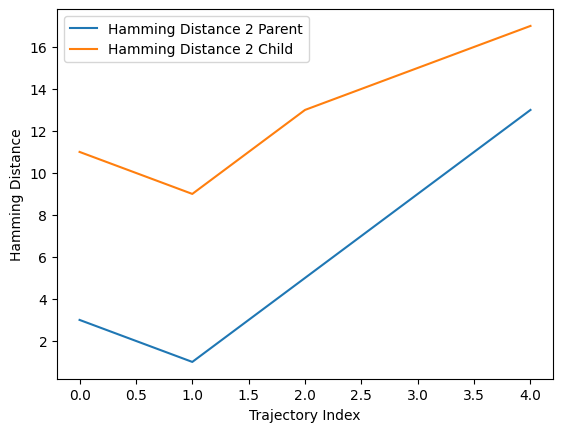

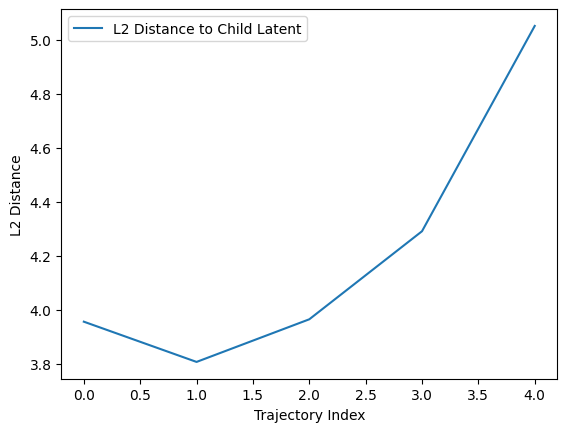

In [54]:
for rp, rc, rlc, slt, sct in zip(real_parent_sequences, real_child_sequences, real_child_latents, sampled_latent_trajectories, sampled_child_trajectories):
    
    print(len(rp), len(rc))
    print(Counter([len(c) for c in sct]))
    
    # calculate hm dists between sct and rp/rc
    p_hm_dists = [calculate_hamming_dist(s, rp) for s in sct]
    c_hm_dists = [calculate_hamming_dist(s, rc) for s in sct]

    # calculate l2 and mse distance between rlc and slt
    c_lat_l2 = [np.linalg.norm(s - rlc) for s in slt]    
    c_lat_mse = [np.mean((s - rlc) ** 2) for s in slt]

    # plot hamming distance to parent and child (y-axis) according to n_traj index (x-axis)
    fig, ax = plt.subplots()
    ax.plot(p_hm_dists, label="Hamming Distance 2 Parent")
    ax.plot(c_hm_dists, label="Hamming Distance 2 Child")
    ax.set_xlabel("Trajectory Index")
    ax.set_ylabel("Hamming Distance")
    ax.legend()
    plt.show()
    
    # plot l2 distance to child latent (y-axis) according to n_traj index (x-axis)
    fig, ax = plt.subplots()
    ax.plot(c_lat_l2, label="L2 Distance to Child Latent")
    ax.set_xlabel("Trajectory Index")
    ax.set_ylabel("L2 Distance")
    ax.legend()
    plt.show()
    
    break